In [1]:
!pip install cirq qiskit==1.4.2 qiskit-aer==0.16.1 amazon-braket-sdk
!pip install matplotlib pylatexenc

  Using cached qiskit_aer-0.16.1-cp312-cp312-win_amd64.whl.metadata (8.4 kB)
Using cached qiskit_aer-0.16.1-cp312-cp312-win_amd64.whl (9.5 MB)
  Attempting uninstall: qiskit-aer
    Found existing installation: qiskit-aer 0.17.2
    Uninstalling qiskit-aer-0.17.2:
      Successfully uninstalled qiskit-aer-0.17.2



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cirq
import matplotlib.pyplot as plt
import numpy as np
import math

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import MCMT

from braket.circuits import Circuit
from braket.devices import LocalSimulator

# Algorithme de grover


In [3]:
n = 6
solution = "110101"
max_iter = round(math.pi / 4 * math.sqrt(2**n))
print(f"Nombre itération : {max_iter}")

Nombre itération : 6


### Version Qiskit

C:\Users\steig\AppData\Local\Temp\ipykernel_11256\66095302.py:1: DeprecationWarning: The class ``qiskit.circuit.library.generalized_gates.mcmt.MCMT`` is deprecated as of qiskit 1.4. It will be removed no earlier than 3 months after the release date. Use MCMTGate instead.
  mcz = MCMT('cz', n-1, 1)


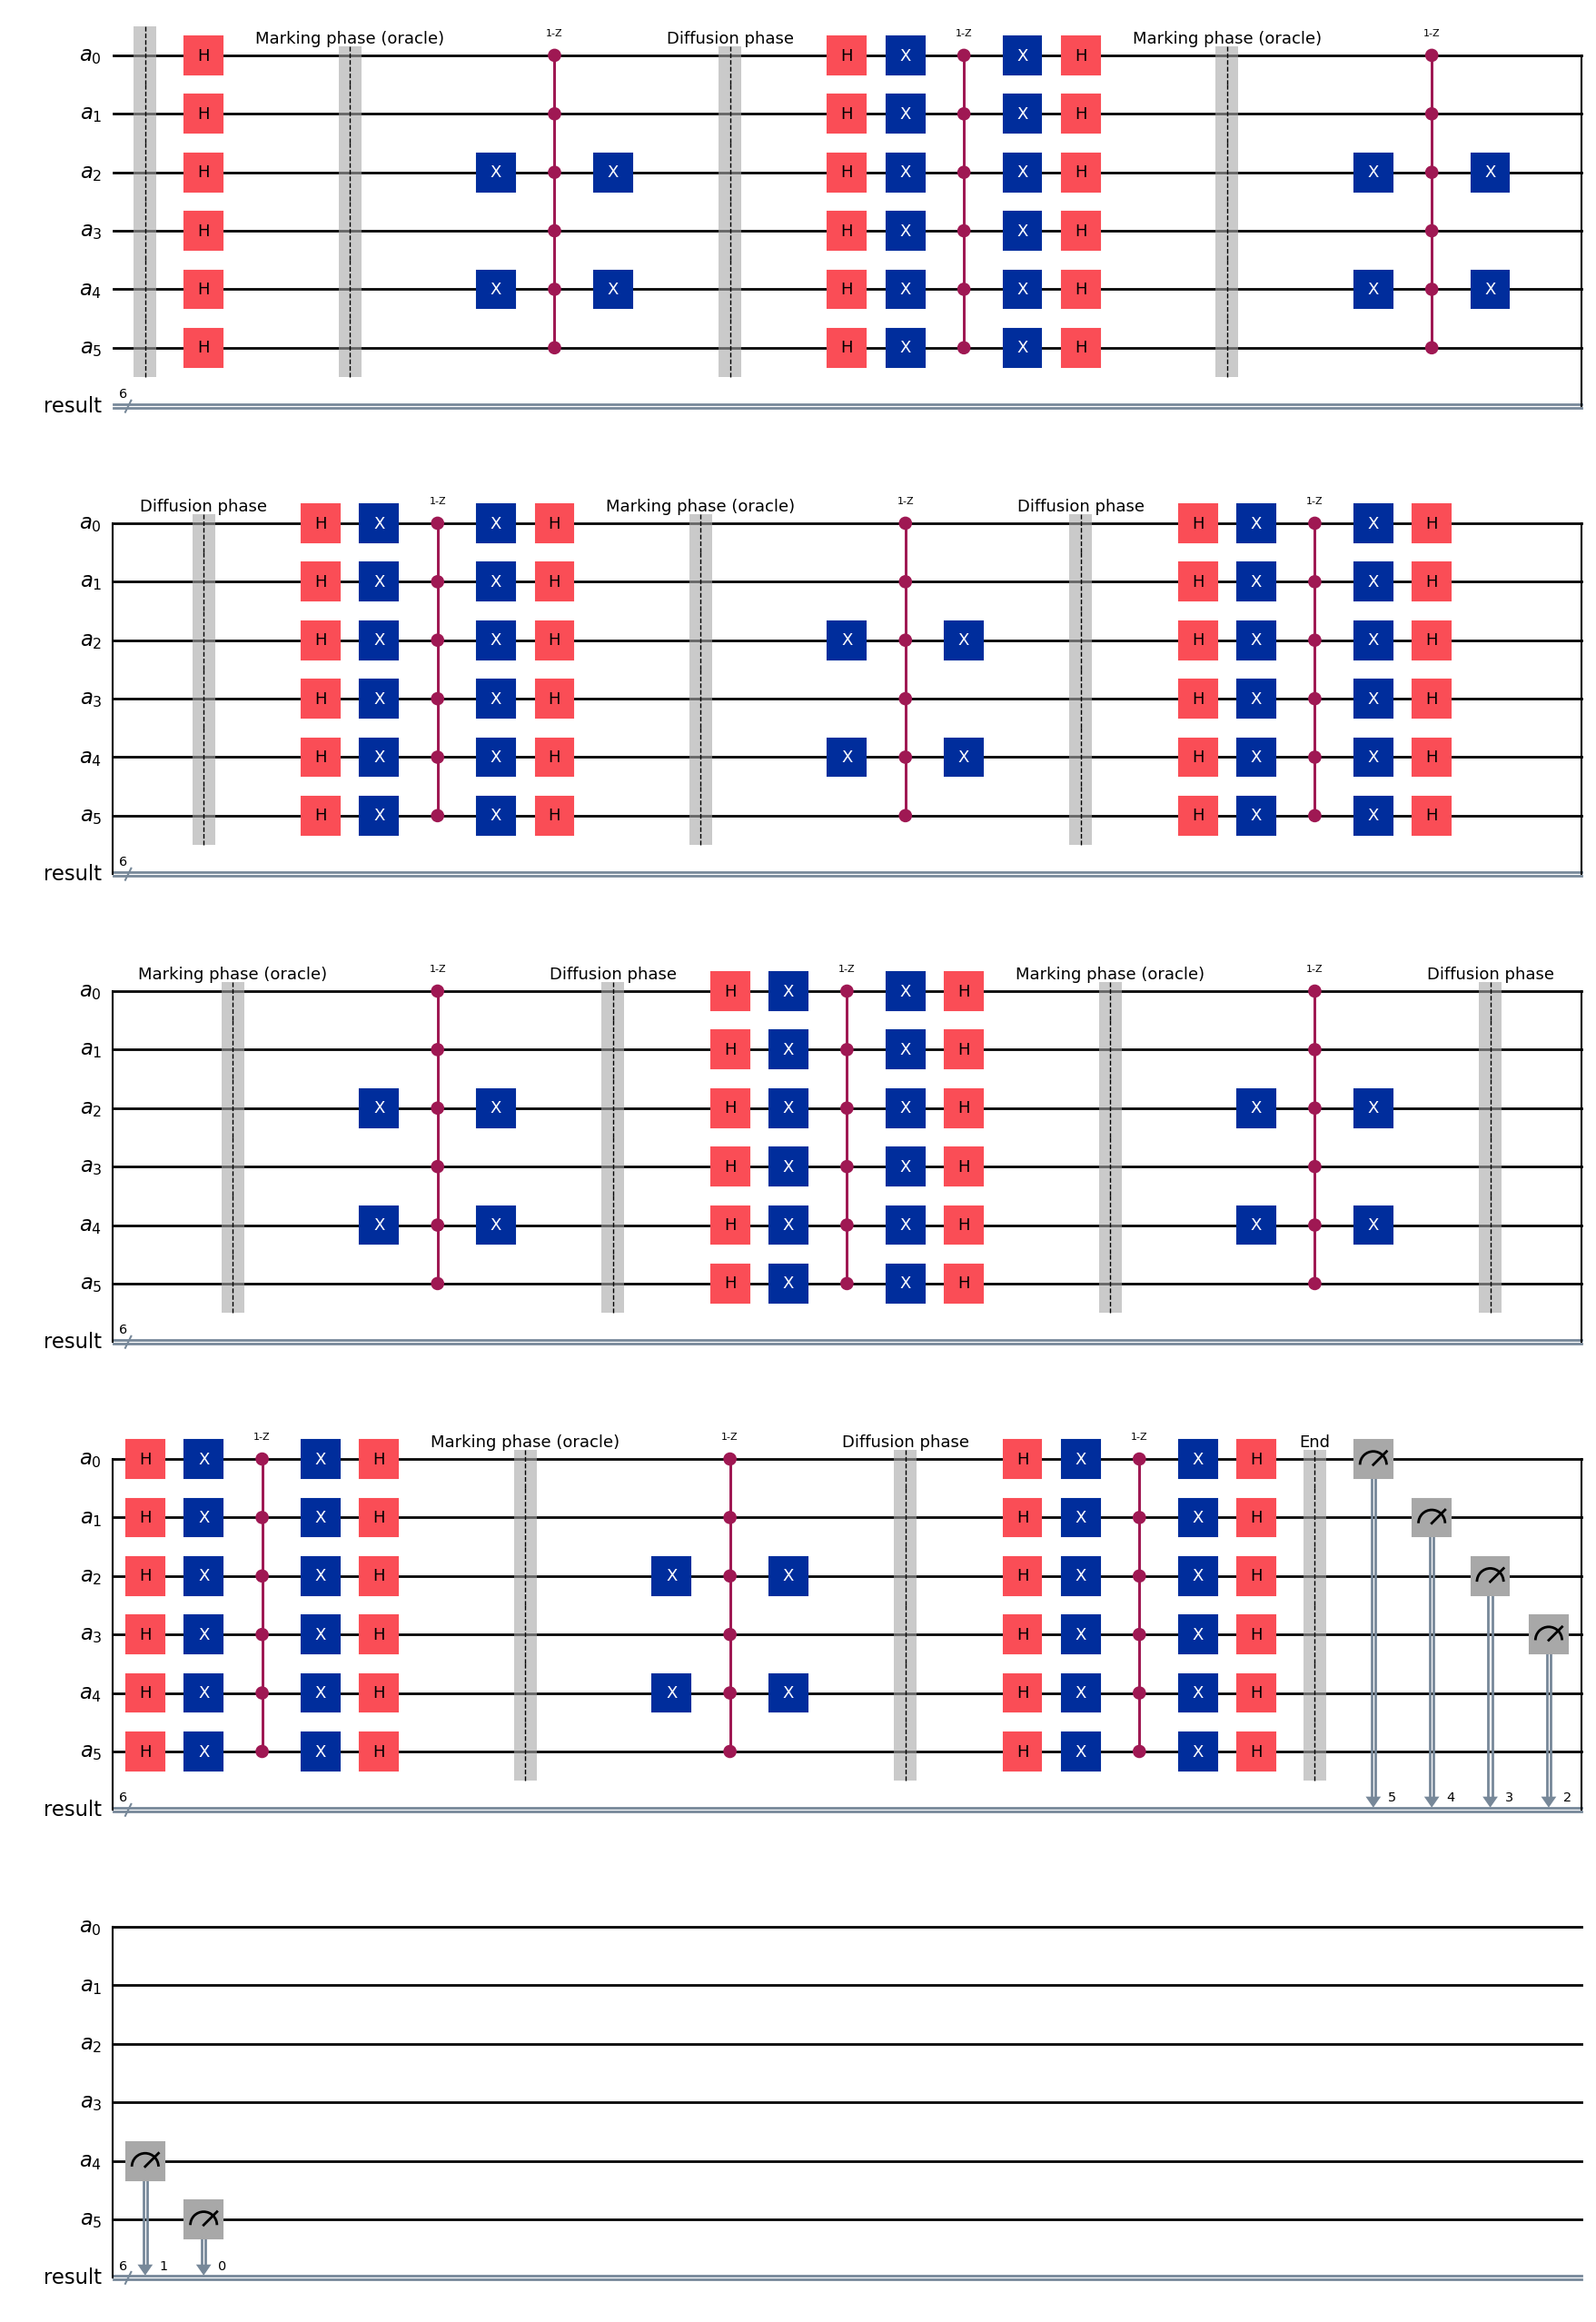

In [36]:
mcz = MCMT('cz', n-1, 1)
# Qbit
a = QuantumRegister(n, "a")
# For results
res = ClassicalRegister(n, "result")

qc = QuantumCircuit(a, res)

qc.barrier()

qc.h(a)

for _ in range(max_iter):
  qc.barrier(label="Marking phase (oracle)")
  for i in range(n):
    if solution[i] == "0":
      qc.x(a[i])

  qc.compose(mcz, inplace=True)

  for i in range(n):
    if solution[i] == "0":
      qc.x(a[i])

  qc.barrier(label="Diffusion phase")

  qc.h(a)
  qc.x(a)
  qc.compose(mcz, inplace=True)
  qc.x(a)
  qc.h(a)

qc.barrier(label="End")

qc.measure(a, res[::-1])
qc.draw(output="mpl")

{'110101': 998, '111010': 1, '111011': 1}


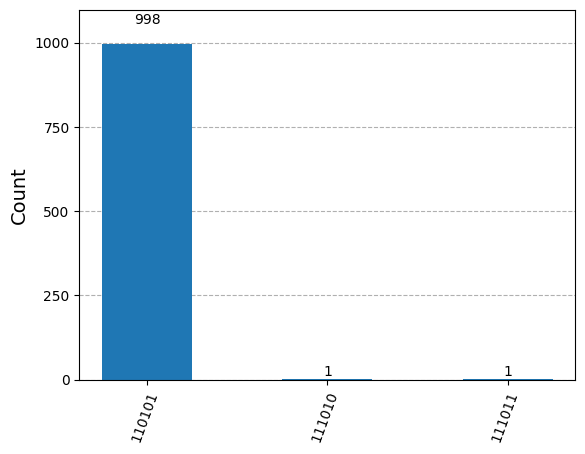

In [37]:
Simulator= AerSimulator()
#Converts your circuit into a form the simulator understands
compile=transpile(qc,Simulator)
#run(...): Executes the circuit
#shots=20: Runs the circuit 20 times
#result(): Gets the execution result
#get_counts(): Returns how many times each result appeared
result= Simulator.run(compile, shots=1000).result().get_counts()
print(result)
plot_histogram(result)

### Version Cirq

In [19]:
import cirq

In [20]:
n = 6
solution = "110101"
max_iter = round(math.pi / 4 * math.sqrt(2**n))

In [23]:
# Circuit
qubits  = cirq.LineQubit.range(n)
circuit = cirq.Circuit()
mcz_gate = cirq.Z.controlled(n - 1)

# Initial superposition
circuit.append(cirq.H.on_each(*qubits))

for _ in range(max_iter):
    ops = []

    # Marking phase
    for i in range(n):
        if solution[i] == "0": ops.append(cirq.X(qubits[i]))

    ops.append(mcz_gate(*qubits))

    for i in range(n):
        if solution[i] == "0": ops.append(cirq.X(qubits[i]))
        
    circuit.append(ops)

    # Diffusion phase
    circuit.append(cirq.H.on_each(*qubits))
    circuit.append(cirq.X.on_each(*qubits))
    circuit.append(mcz_gate(*qubits))
    circuit.append(cirq.X.on_each(*qubits))
    circuit.append(cirq.H.on_each(*qubits))

# Measures
circuit.append(cirq.measure(*qubits, key="result"))
result = cirq.Simulator().run(circuit, repetitions=1000)
print(result.histogram(key="result"))

Counter({53: 996, 31: 1, 3: 1, 37: 1, 30: 1})


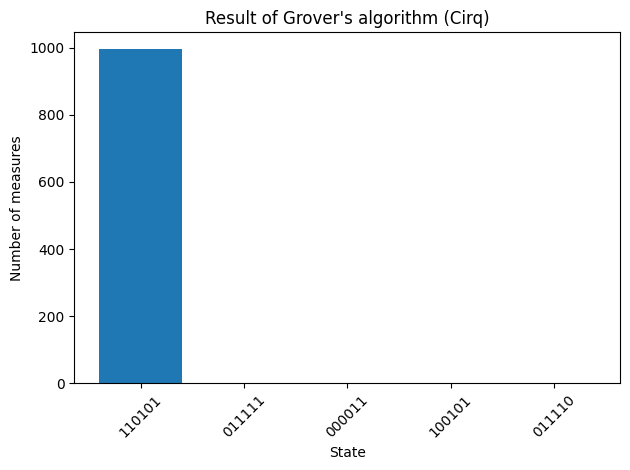

In [32]:
import matplotlib.pyplot as plt

histogram = result.histogram(key="result")
labels = [format(state, f"0{n}b") for state in histogram.keys()]
values = list(histogram.values())

plt.bar(labels, values)
plt.xlabel("State")
plt.ylabel("Number of measures")
plt.title("Result of Grover's algorithm (Cirq)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Version Pennylane

In [27]:
import pennylane as qml, math

In [ ]:
n = 6
solution = "110101"
max_iter = round(math.pi / 4 * math.sqrt(2**n))

In [ ]:
wires = list(range(n))
dev = qml.device("default.qubit", wires=wires)

def oracle():
    for i in range(n):
        if solution[i] == "0": qml.PauliX(wires=i)
    qml.ctrl(qml.PauliZ, control=wires[:-1])(wires=wires[-1])
    for i in range(n):
        if solution[i] == "0": qml.PauliX(wires=i)

def diffusion():
    for i in wires: qml.Hadamard(wires=i)
    for i in wires: qml.PauliX(wires=i)
    qml.ctrl(qml.PauliZ, control=wires[:-1])(wires=wires[-1])
    for i in wires: qml.PauliX(wires=i)
    for i in wires: qml.Hadamard(wires=i)

@qml.qnode(dev)
def grover():
    for i in wires:
        qml.Hadamard(wires=i)
    for _ in range(max_iter):
        oracle()
        diffusion()
    return qml.probs(wires=wires)

probs  = grover()
counts = {format(i, f"0{n}b"): int(p * 1000)
          for i, p in enumerate(probs) if p > 0.01}
print(counts)

{'110101': 996}


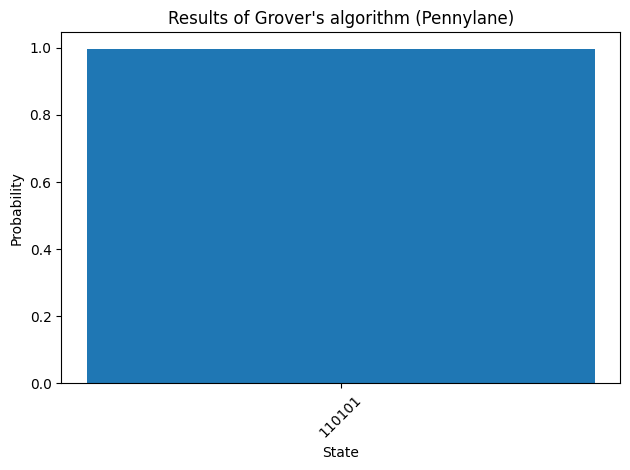

In [33]:
labels = [format(i, f"0{n}b") for i, p in enumerate(probs) if p > 0.01]
values = [p for p in probs if p > 0.01]

plt.bar(labels, values)
plt.xlabel("State")
plt.ylabel("Probability")
plt.title("Results of Grover's algorithm (Pennylane)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Rapport

## Questions

### 1. Generation of the uniform superposition state

Question: "How is the uniform superposition state generated from the initial state ∣ 00 … 0⟩?"

### 2. Implementation of the Oracle 

Question: "How is the oracle implemented to mark the target state ∣ 𝜔⟩?"

### 3. Implementation of the diffusion operator

Question: "How is the diffusion operator 𝐷 implemented in each environment?"

### 4. Evolution of probability distribution

Question: "How does the probability distribution evolve after each Grover iteration?"

### 5. Optimal number of iterations

Question: 
- "Demonstrate why the optimal number of Grover iterations is approximately 
    𝑘 ≈ (𝜋 / 4) * √𝑁
and explain why applying additional iterations can decrease the probability amplitude of the marked state ∣ 𝜔⟩."

### 6. Differences between environnements

Question: "What are the main differences between Qiskit and the two selected environments in terms of syntax, abstraction level, usability, and execution workflow?"